In [1]:
import sys
print(sys.executable)


/home/leesungwon/miniconda3/envs/eda/bin/python


In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

DATASETS = {
    'traffic_generator': [
        Path('model/dataset.jsonl'),
        Path('dataset.jsonl'),
        Path('../model/dataset.jsonl'),
        Path('../dataset.jsonl'),
    ],
    'uni1': [
        Path('dataset_univ1.jsonl'),
        Path('../dataset_univ1.jsonl'),
        Path('model/dataset_univ1.jsonl'),
    ],
}

FEATURE_NAMES = [
    'frame_len',
    'ip_len',
    'ip_ttl',
    'tcp_payload_bytes',
    'tcp_flags',
    'tcp_window_size',
    'iat_us',
    'retransmission',
    'out_of_order',
    'duplicate_ack',
    'fast_retransmission',
]


def resolve_path(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('dataset jsonl 파일을 찾지 못했습니다: ' + ', '.join(map(str, candidates)))


def load_flow_dataset(path, dataset_name):
    meta_rows = []
    packet_rows = []

    with Path(path).open('r', encoding='utf-8') as f:
        for row_id, line in enumerate(f, start=1):
            if not line.strip():
                continue

            sample = json.loads(line)
            flow_key = sample.get('flow_key', {})
            trace_key = sample.get('trace_key', {})
            x = np.asarray(sample.get('x', []), dtype=float)

            if x.ndim != 2 or x.shape[1] != len(FEATURE_NAMES):
                raise ValueError(f'{path}:{row_id} x shape이 예상과 다릅니다: {x.shape}')

            src_index = flow_key.get('src_index', 0)
            flow_id = flow_key.get('flow_id', flow_key.get('tcp_stream', row_id))
            source_file = flow_key.get('source_file', trace_key.get('source_file', ''))
            tcp_stream = flow_key.get('tcp_stream', trace_key.get('tcp_stream', np.nan))
            direction = flow_key.get('direction', '')
            directional_size = sample.get('directional_size_bytes', 0)
            flow_size = sample.get('flow_size_bytes', directional_size)
            label = sample.get('label')

            meta = {
                'dataset': dataset_name,
                'row_id': row_id,
                'src_index': src_index,
                'flow_id': flow_id,
                'source_file': source_file,
                'tcp_stream': tcp_stream,
                'direction': direction,
                'directional_size_bytes': directional_size,
                'flow_size_bytes': flow_size,
                'label': label,
                'packet_count': x.shape[0],
                'x_mean': float(x.mean()),
            }

            for col_idx, feature_name in enumerate(FEATURE_NAMES):
                values = x[:, col_idx]
                meta[f'{feature_name}_mean'] = float(values.mean())
                meta[f'{feature_name}_first'] = float(values[0])
                meta[f'{feature_name}_last'] = float(values[-1])

            meta_rows.append(meta)

            for packet_index, values in enumerate(x):
                packet_row = {
                    'dataset': dataset_name,
                    'row_id': row_id,
                    'flow_id': flow_id,
                    'source_file': source_file,
                    'tcp_stream': tcp_stream,
                    'direction': direction,
                    'packet_index': packet_index,
                    'label': label,
                    'flow_size_bytes': flow_size,
                    'directional_size_bytes': directional_size,
                }
                packet_row.update(dict(zip(FEATURE_NAMES, values)))
                packet_rows.append(packet_row)

    return pd.DataFrame(meta_rows), pd.DataFrame(packet_rows)


loaded = {}
flow_frames = []
packet_frames = []

for dataset_name, candidates in DATASETS.items():
    path = resolve_path(candidates)
    flow_df, flow_packet_df = load_flow_dataset(path, dataset_name)
    loaded[dataset_name] = path
    flow_frames.append(flow_df)
    packet_frames.append(flow_packet_df)

all_df = pd.concat(flow_frames, ignore_index=True)
all_packet_df = pd.concat(packet_frames, ignore_index=True)

tg_df = all_df[all_df['dataset'] == 'traffic_generator'].copy()
uni1_df = all_df[all_df['dataset'] == 'uni1'].copy()
tg_packet_df = all_packet_df[all_packet_df['dataset'] == 'traffic_generator'].copy()
uni1_packet_df = all_packet_df[all_packet_df['dataset'] == 'uni1'].copy()

print('loaded paths:')
for name, path in loaded.items():
    print(f'- {name}: {path}')

print('')
print('flow counts:')
print(all_df.groupby(['dataset', 'label']).size())

display(all_df.groupby('dataset')[['flow_size_bytes', 'directional_size_bytes', 'x_mean']].agg(['count', 'mean', 'median', 'min', 'max']))
display(all_df.head())


loaded paths:
- traffic_generator: dataset.jsonl
- uni1: ../dataset_univ1.jsonl

flow counts:
dataset            label
traffic_generator  0         1254
                   1          136
uni1               0        68524
                   1        17133
dtype: int64


flow_size_bytes                                         \
                            count           mean   median min        max   
dataset                                                                    
traffic_generator            1390  804962.967626     40.0  20   19606016   
uni1                        85657  116464.105619  11314.0   1  682769160   

                  directional_size_bytes                              \
                                   count           mean   median min   
dataset                                                                
traffic_generator                   1390  804962.967626     40.0  20   
uni1                               85657  116464.105619  11314.0   1   

                             x_mean                                           \
                         max  count          mean        median          min   
dataset                                                                        
traffic_generator   19606016   1390  11272.733870   4433.909091  4253.022727   
uni1               682769160  85657  40658.403554  11423.159091    36.125000   

                                 
                            max  
dataset                          
traffic_generator  1.031359e+05  
uni1               3.754950e+06

,dataset,row_id,src_index,flow_id,source_file,tcp_stream,direction,directional_size_bytes,flow_size_bytes,label,...,retransmission_last,out_of_order_mean,out_of_order_first,out_of_order_last,duplicate_ack_mean,duplicate_ack_first,duplicate_ack_last,fast_retransmission_mean,fast_retransmission_first,fast_retransmission_last
0,traffic_generator,1,0,1,,NaN,src_to_dst,20,20,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,traffic_generator,2,0,2,,NaN,src_to_dst,20,20,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,traffic_generator,3,0,3,,NaN,src_to_dst,20,20,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,traffic_generator,4,0,4,,NaN,src_to_dst,20,20,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,traffic_generator,5,0,6,,NaN,src_to_dst,20,20,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


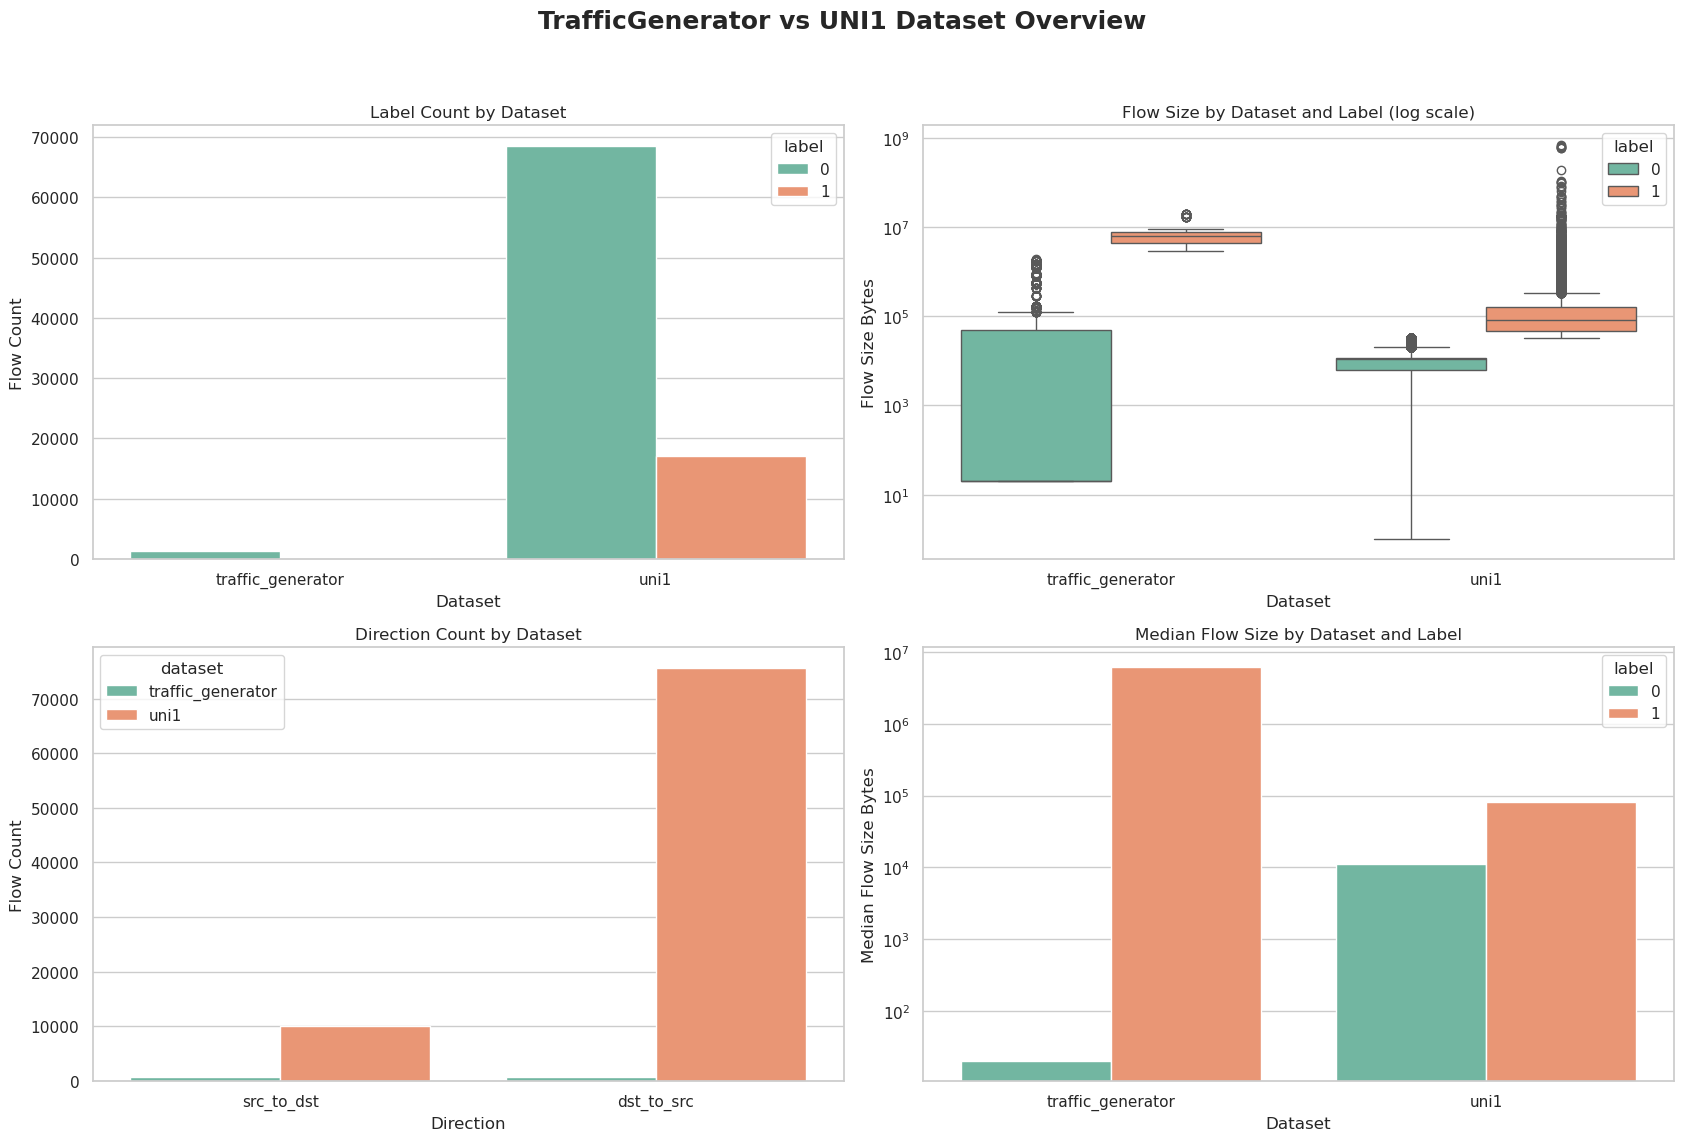

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(17, 12))
fig.suptitle('TrafficGenerator vs UNI1 Dataset Overview', fontsize=18, fontweight='bold')

sns.countplot(x='dataset', hue='label', data=all_df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Label Count by Dataset')
axes[0, 0].set_xlabel('Dataset')
axes[0, 0].set_ylabel('Flow Count')

sns.boxplot(x='dataset', y='flow_size_bytes', hue='label', data=all_df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Flow Size by Dataset and Label (log scale)')
axes[0, 1].set_xlabel('Dataset')
axes[0, 1].set_ylabel('Flow Size Bytes')

sns.countplot(x='direction', hue='dataset', data=all_df, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Direction Count by Dataset')
axes[1, 0].set_xlabel('Direction')
axes[1, 0].set_ylabel('Flow Count')

summary = all_df.groupby(['dataset', 'label'])['flow_size_bytes'].median().reset_index()
sns.barplot(x='dataset', y='flow_size_bytes', hue='label', data=summary, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Median Flow Size by Dataset and Label')
axes[1, 1].set_xlabel('Dataset')
axes[1, 1].set_ylabel('Median Flow Size Bytes')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


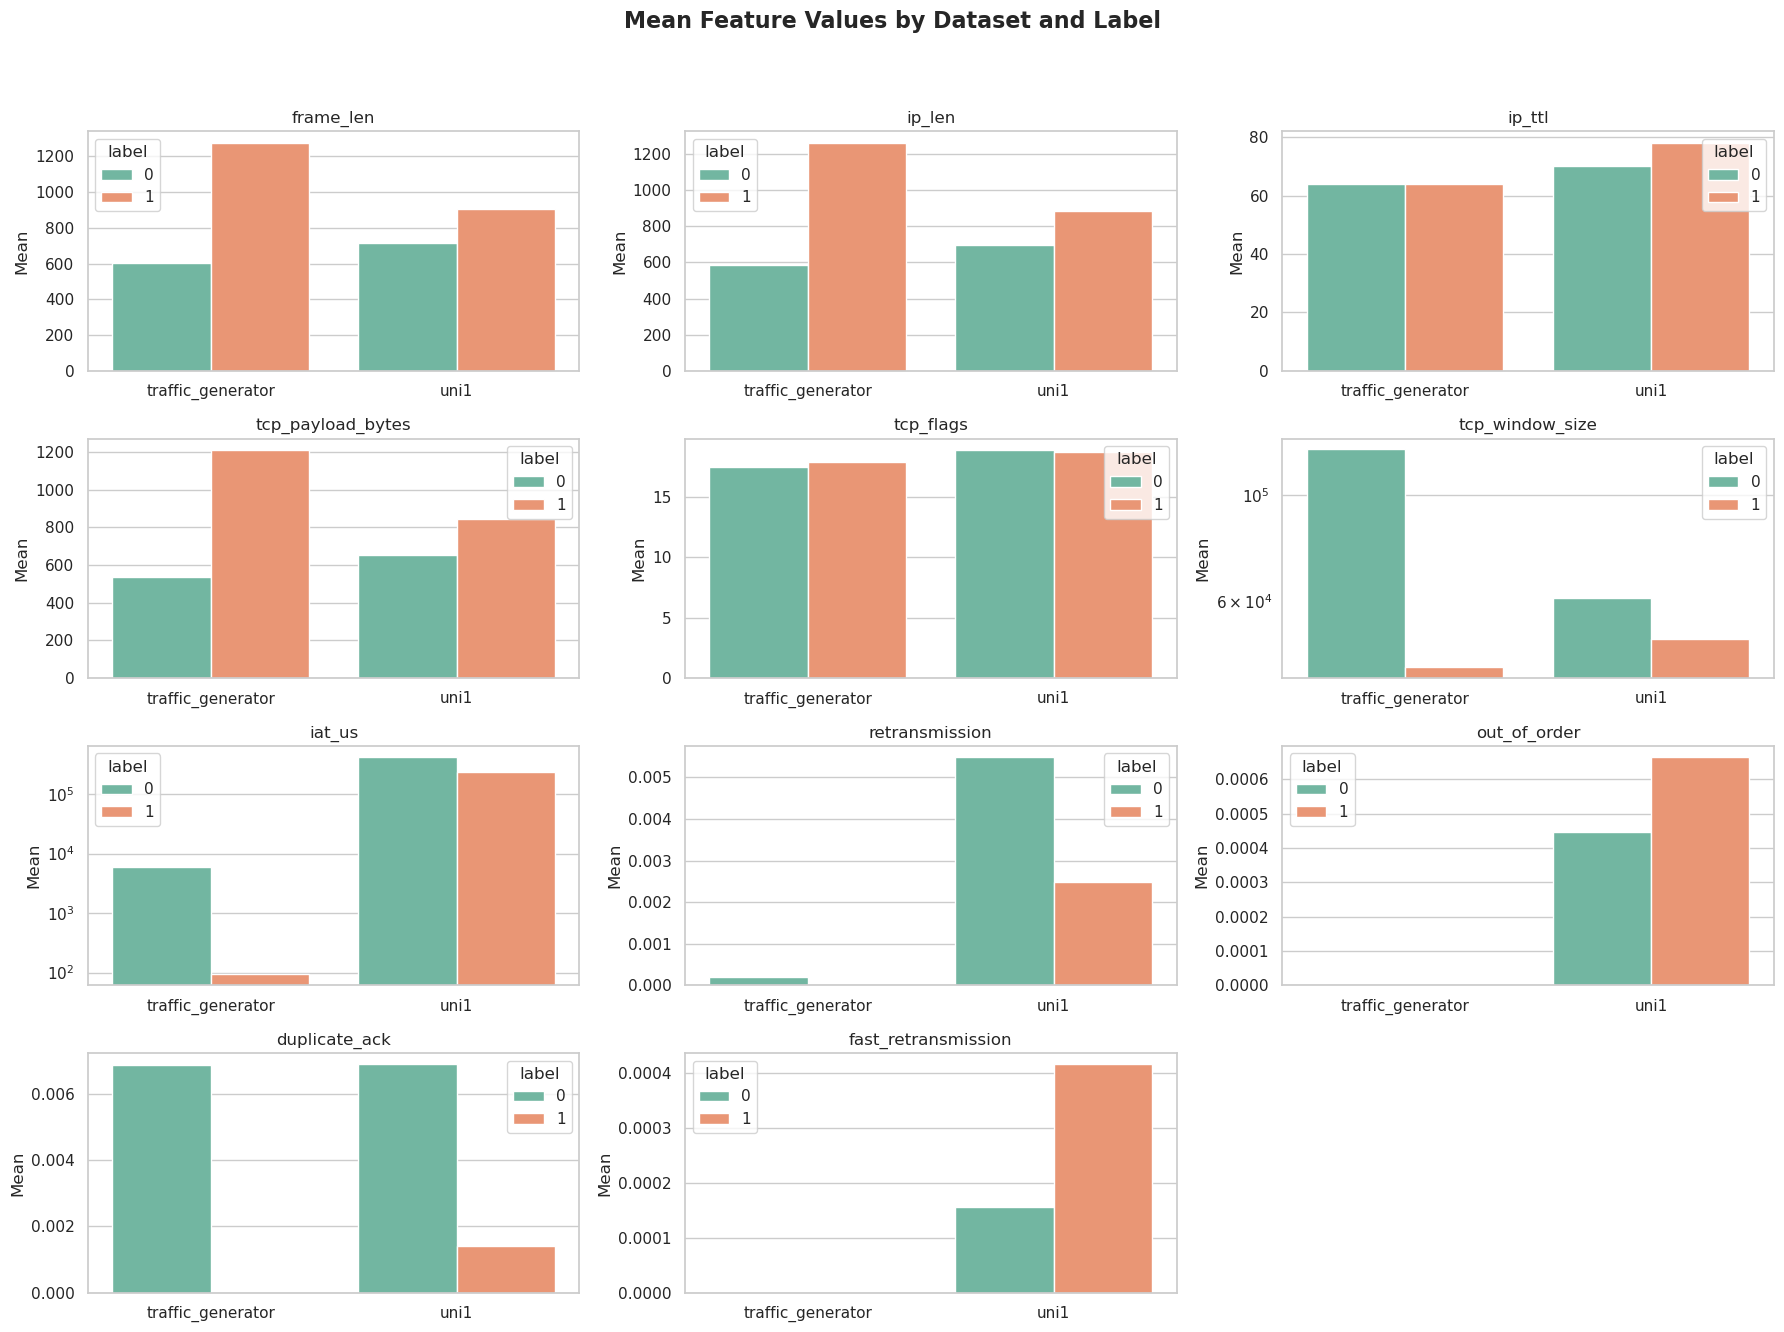

In [4]:
feature_mean_cols = [f'{name}_mean' for name in FEATURE_NAMES]
feature_compare = all_df.groupby(['dataset', 'label'])[feature_mean_cols].mean().reset_index()

fig, axes = plt.subplots(4, 3, figsize=(18, 14))
fig.suptitle('Mean Feature Values by Dataset and Label', fontsize=16, fontweight='bold')

for i, feature_name in enumerate(FEATURE_NAMES):
    ax = axes[i // 3, i % 3]
    sns.barplot(
        x='dataset',
        y=f'{feature_name}_mean',
        hue='label',
        data=feature_compare,
        ax=ax,
        palette='Set2',
    )
    if feature_name in ['iat_us', 'tcp_window_size']:
        ax.set_yscale('log')
    ax.set_title(feature_name)
    ax.set_xlabel('')
    ax.set_ylabel('Mean')

axes[3, 2].axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


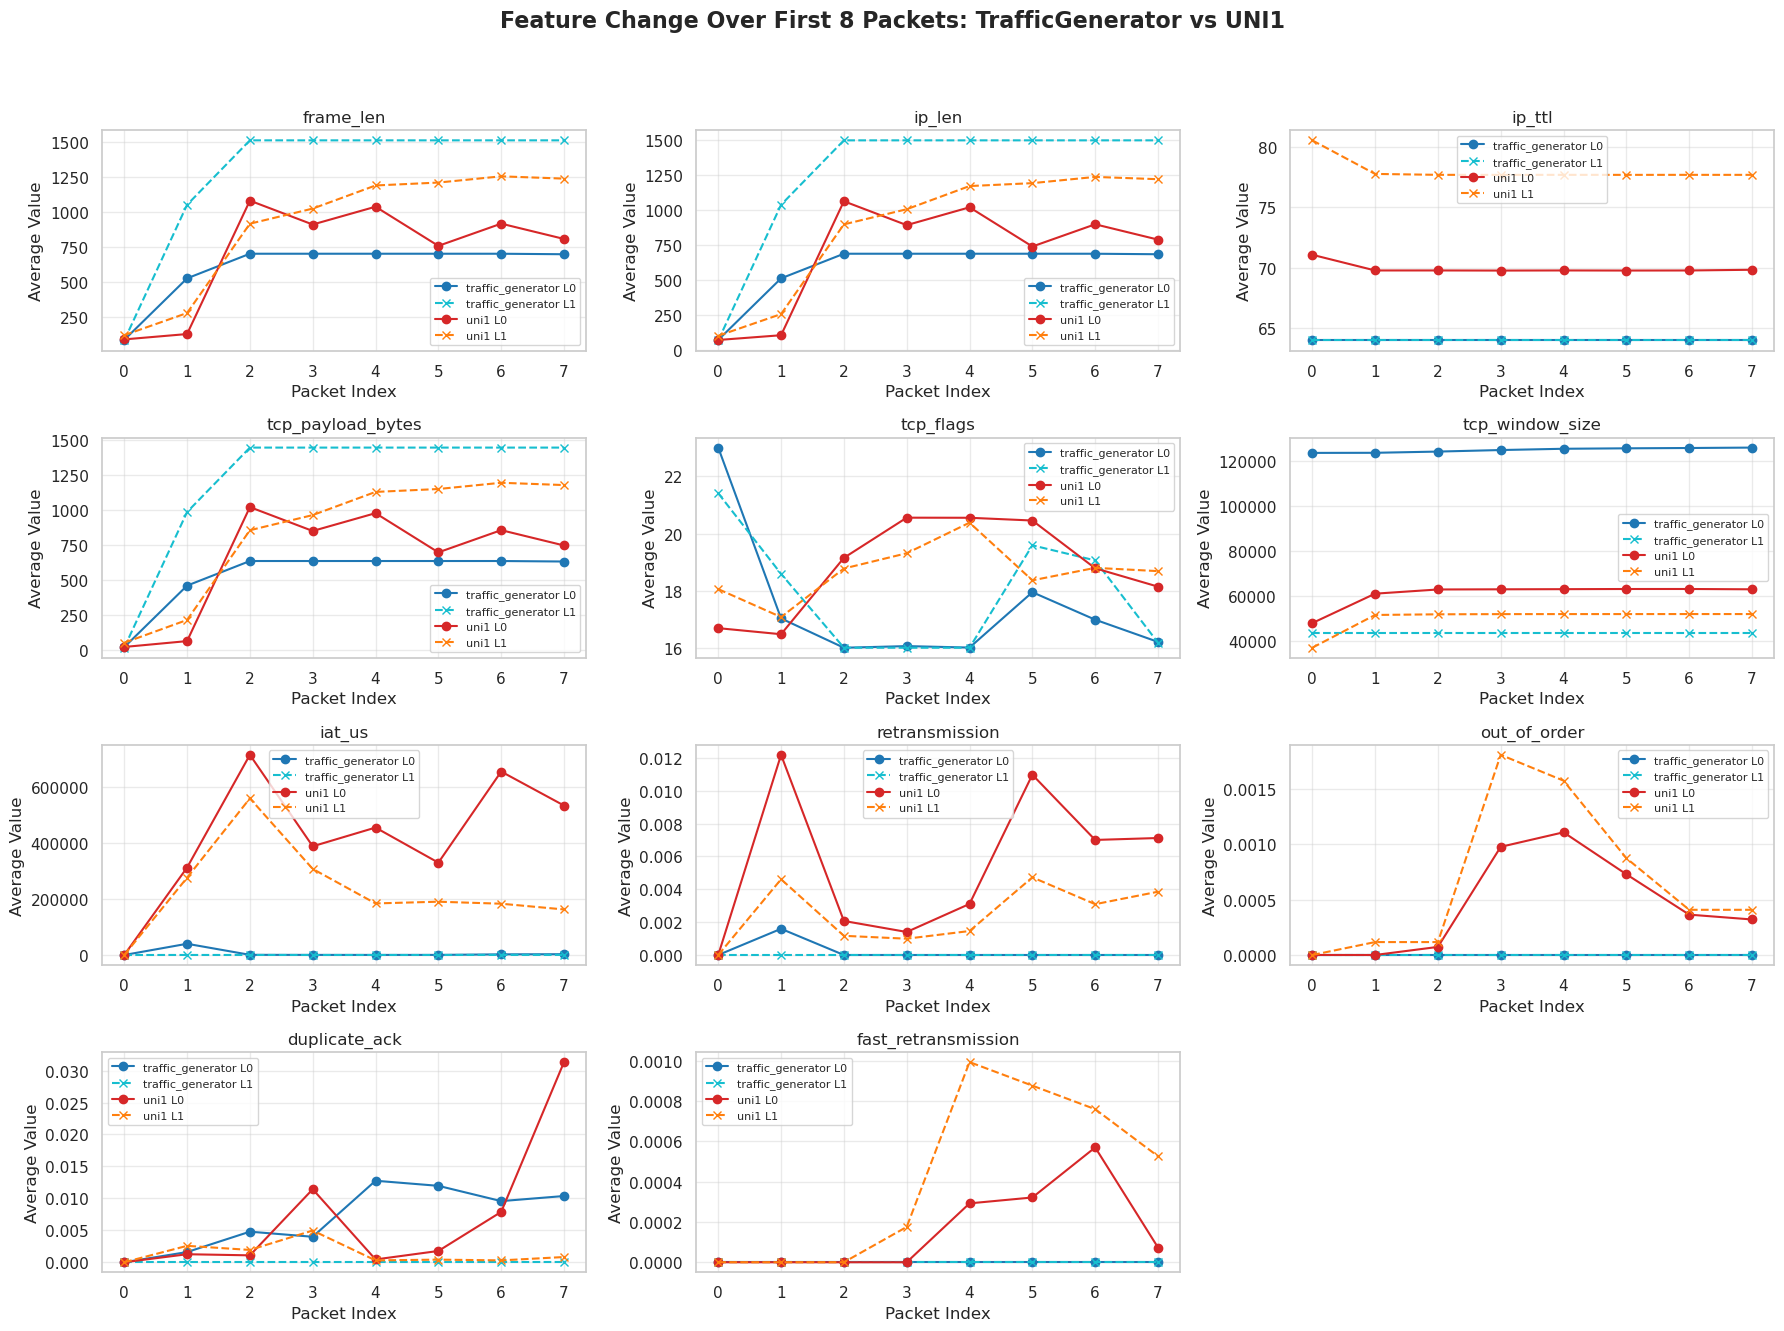

In [5]:
avg_by_label = all_packet_df.groupby(['dataset', 'label', 'packet_index'])[FEATURE_NAMES].mean().reset_index()

fig, axes = plt.subplots(4, 3, figsize=(18, 14))
fig.suptitle('Feature Change Over First 8 Packets: TrafficGenerator vs UNI1', fontsize=16, fontweight='bold')

styles = {
    ('traffic_generator', 0): ('tab:blue', 'o', '-'),
    ('traffic_generator', 1): ('tab:cyan', 'x', '--'),
    ('uni1', 0): ('tab:red', 'o', '-'),
    ('uni1', 1): ('tab:orange', 'x', '--'),
}

for i, feature_name in enumerate(FEATURE_NAMES):
    ax = axes[i // 3, i % 3]
    for (dataset_name, label), (color, marker, linestyle) in styles.items():
        subset = avg_by_label[(avg_by_label['dataset'] == dataset_name) & (avg_by_label['label'] == label)]
        if subset.empty:
            continue
        ax.plot(
            subset['packet_index'],
            subset[feature_name],
            label=f'{dataset_name} L{label}',
            color=color,
            marker=marker,
            linestyle=linestyle,
        )
    ax.set_title(feature_name)
    ax.set_xlabel('Packet Index')
    ax.set_ylabel('Average Value')
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8)

axes[3, 2].axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [6]:
summary = all_df.groupby(['dataset', 'label'])[['flow_size_bytes', 'directional_size_bytes', 'x_mean'] + feature_mean_cols].agg(['mean', 'median', 'std'])
summary


flow_size_bytes                           \
                                   mean     median           std   
dataset           label                                            
traffic_generator 0        1.321538e+05       20.0  3.573096e+05   
                  1        7.008660e+06  6156810.0  4.396224e+06   
uni1              0        1.056494e+04    11131.0  6.247184e+03   
                  1        5.400113e+05    82422.0  1.202805e+07   

                        directional_size_bytes                           \
                                          mean     median           std   
dataset           label                                                   
traffic_generator 0               1.321538e+05       20.0  3.573096e+05   
                  1               7.008660e+06  6156810.0  4.396224e+06   
uni1              0               1.056494e+04    11131.0  6.247184e+03   
                  1               5.400113e+05    82422.0  1.202805e+07   

                               x_mean                               \
                                 mean        median            std   
dataset           label                                              
traffic_generator 0      12027.512895   4967.642045   13615.872838   
                  1       4313.227273   4326.710227      21.311043   
uni1              0      44320.549064  11524.340909  203623.750681   
                  1      26011.531496   8744.704545   92301.907808   

                        frame_len_mean  ... retransmission_mean  \
                                  mean  ...                 std   
dataset           label                 ...                       
traffic_generator 0         601.595295  ...            0.004990   
                  1        1276.941176  ...            0.000000   
uni1              0         715.736601  ...            0.043562   
                  1         904.118835  ...            0.027517   

                        out_of_order_mean                  duplicate_ack_mean  \
                                     mean median       std               mean   
dataset           label                                                         
traffic_generator 0              0.000000    0.0  0.000000           0.006878   
                  1              0.000000    0.0  0.000000           0.000000   
uni1              0              0.000447    0.0  0.009834           0.006897   
                  1              0.000664    0.0  0.011321           0.001408   

                                         fast_retransmission_mean         \
                        median       std                     mean median   
dataset           label                                                    
traffic_generator 0        0.0  0.061083                 0.000000    0.0   
                  1        0.0  0.000000                 0.000000    0.0   
uni1              0        0.0  0.032480                 0.000157    0.0   
                  1        0.0  0.013466                 0.000416    0.0   

                                   
                              std  
dataset           label            
traffic_generator 0      0.000000  
                  1      0.000000  
uni1              0      0.004426  
                  1      0.007324  

[4 rows x 42 columns]